In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
def compute_fft(signal, fs=360):
    N = len(signal)
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)
    return freqs[:N//2], np.abs(fft_vals[:N//2])

def plot_fft(signal, fs=360, title="FFT"):
    freqs, magnitude = compute_fft(signal, fs)
    
    plt.figure(figsize=(8,4))
    plt.semilogy(freqs, magnitude)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (log scale)")
    plt.grid()
    plt.xlim(0, 100)
    plt.show()

C:\Users\ASUS\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ASUS\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Processing: 100.csv


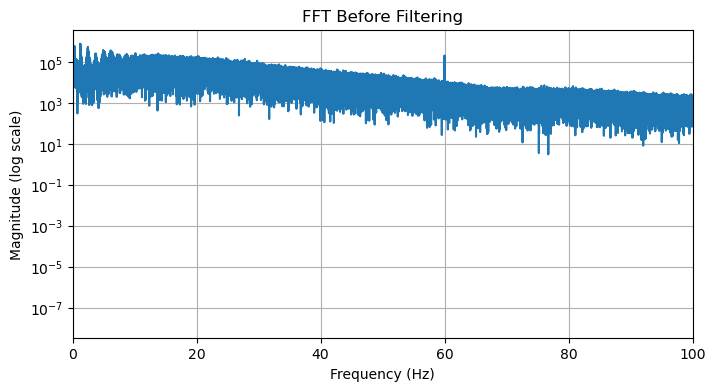

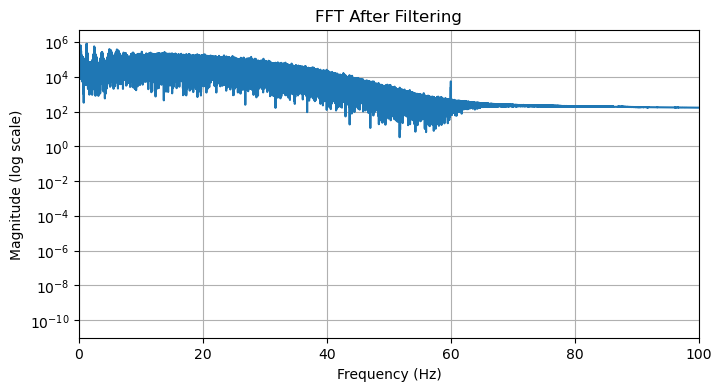

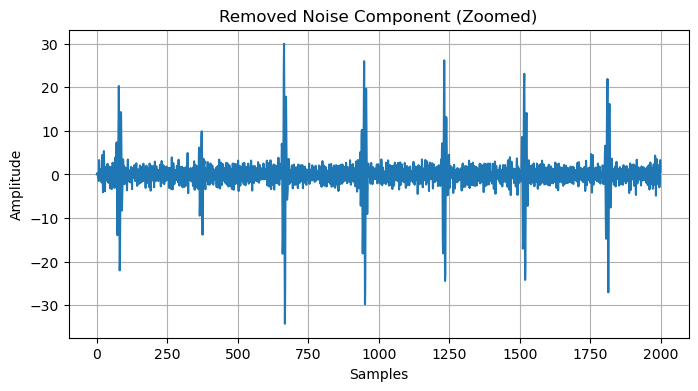

Processing: 101.csv
Processing: 102.csv
Processing: 103.csv
Processing: 104.csv
Processing: 105.csv
Processing: 106.csv
Processing: 107.csv
Processing: 108.csv
Processing: 109.csv
Processing: 111.csv
Processing: 112.csv
Processing: 113.csv
Processing: 114.csv
Processing: 115.csv
Processing: 116.csv
Processing: 117.csv
Processing: 118.csv
Processing: 119.csv
Processing: 121.csv
Processing: 122.csv
Processing: 123.csv
Processing: 124.csv
Processing: 200.csv
Processing: 201.csv
Processing: 202.csv
Processing: 203.csv
Processing: 205.csv
Processing: 207.csv
Processing: 208.csv
Processing: 209.csv
Processing: 210.csv
Processing: 212.csv
Processing: 213.csv
Processing: 214.csv
Processing: 215.csv
Processing: 217.csv
Processing: 219.csv
Processing: 220.csv
Processing: 221.csv
Processing: 222.csv
Processing: 223.csv
Processing: 228.csv
Processing: 230.csv
Processing: 231.csv
Processing: 232.csv
Processing: 233.csv
Processing: 234.csv
Total files processed: 48


In [2]:
import os
import numpy as np 
import pandas as pd

def lowpass_filter(signal, cutoff=40, fs=360, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff/nyq, btype='low')
    return filtfilt(b, a, signal)

def load_ecg(file):
    data = pd.read_csv(file)
    return data.iloc[:, 1].values   # MLII column
# PROCESS ALL CSV FILES

folder_path = R"C:\Users\ASUS\Documents\Python\New folder\mitbih_database"

csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

all_clean_ecg = []   # store all processed signals

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    print("Processing:", file)
    
    # Load ECG
    ecg = load_ecg(file_path)
    
    # Remove DC offset
    ecg = ecg - np.mean(ecg)
    
    # Apply filter
    clean_ecg = lowpass_filter(ecg)
    
    # Remove DC again after filtering
    clean_ecg = clean_ecg - np.mean(clean_ecg)
    
    # Store processed signal
    all_clean_ecg.append(clean_ecg)
    
    # Plot ONLY for first file (avoid 48 graphs)
    if file == csv_files[0]:
        plot_fft(ecg, title="FFT Before Filtering")
        plot_fft(clean_ecg, title="FFT After Filtering")
        
        noise = ecg - clean_ecg
        
        plt.figure(figsize=(8,4))
        plt.plot(noise[:2000])
        plt.title("Removed Noise Component (Zoomed)")
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.grid()
        plt.show()

print("Total files processed:", len(all_clean_ecg))

In [3]:
df = pd.read_csv(R"C:\Users\ASUS\Documents\Python\New folder\mitbih_database\100.csv")
print(df.head())

   'sample #'  'MLII'  'V5'
0           0     995  1011
1           1     995  1011
2           2     995  1011
3           3     995  1011
4           4     995  1011


In [4]:
def load_ecg(file):
    data = pd.read_csv(file)
    
    # ✅ directly select ECG column (MLII is column 1)
    return data.iloc[:, 1].values

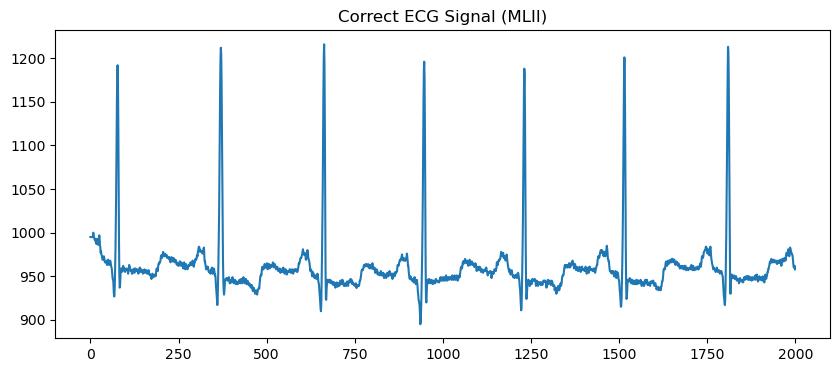

In [5]:
ecg = load_ecg(R"C:\Users\ASUS\Documents\Python\New folder\mitbih_database\100.csv")

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(ecg[:2000])
plt.title("Correct ECG Signal (MLII)")
plt.show()

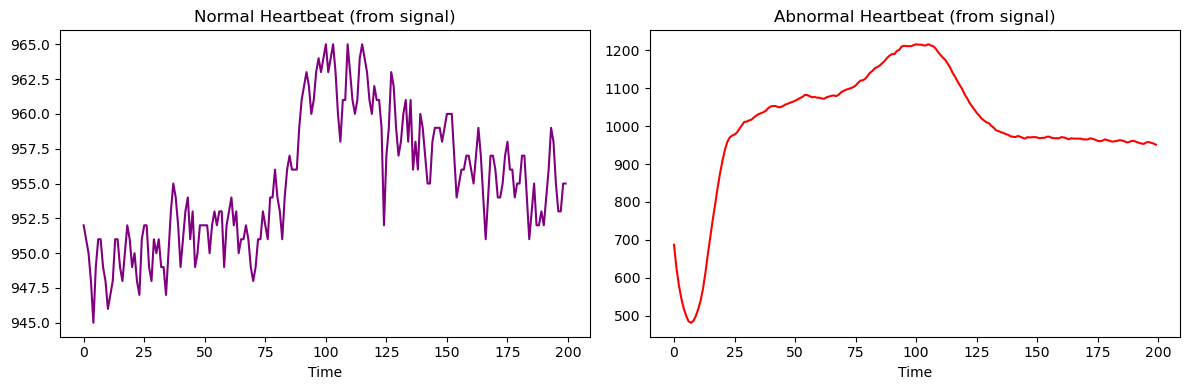

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load ECG
ecg = load_ecg(R"C:\Users\ASUS\Documents\Python\New folder\mitbih_database\100.csv")

# STEP 1: Detect R-peaks
peaks, _ = find_peaks(ecg, distance=200, height=np.mean(ecg))

# STEP 2: Extract beats
window = 100  # samples before and after peak

beats = []
for p in peaks:
    if p - window > 0 and p + window < len(ecg):
        beat = ecg[p-window:p+window]
        beats.append(beat)

beats = np.array(beats)

# STEP 3: Pick normal & abnormal
# Use amplitude variability as rough indicator

stds = np.std(beats, axis=1)

normal_idx = np.argmin(stds)      # most stable beat
abnormal_idx = np.argmax(stds)    # most irregular beat

normal_beat = beats[normal_idx]
abnormal_beat = beats[abnormal_idx]

# STEP 4: Plot side by side
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(normal_beat, color='purple')
plt.title("Normal Heartbeat (from signal)")
plt.xlabel("Time")

plt.subplot(1,2,2)
plt.plot(abnormal_beat, color='red')
plt.title("Abnormal Heartbeat (from signal)")
plt.xlabel("Time")

plt.tight_layout()
plt.show()

In [7]:
from scipy.signal import find_peaks

def segment_beats(ecg_signal, window=100):
    
    # ONLY remove baseline (no normalization, no squaring)
    ecg_signal = ecg_signal - np.mean(ecg_signal)
    
    # SIMPLE and STRONG peak detection
    peaks, _ = find_peaks(
        ecg_signal,
        distance=150,          # spacing between beats
    )
    
    print("Peaks detected:", len(peaks))
    
    beats = []
    
    for p in peaks:
        if p - window > 0 and p + window < len(ecg_signal):
            beat = ecg_signal[p-window:p+window]
            
            if len(beat) == 2*window:
                beats.append(beat)
    
    return beats

In [8]:
beats_test = segment_beats(all_clean_ecg[0])
print("Beats in first file:", len(beats_test))

Peaks detected: 2418
Beats in first file: 2416


In [9]:
all_beats = []

for ecg in all_clean_ecg:
    beats = segment_beats(ecg)
    all_beats.extend(beats)

print("Total beats extracted:", len(all_beats))

Peaks detected: 2418
Peaks detected: 3572
Peaks detected: 2341
Peaks detected: 3251
Peaks detected: 2427
Peaks detected: 2626
Peaks detected: 3306
Peaks detected: 2170
Peaks detected: 3428
Peaks detected: 2544
Peaks detected: 3222
Peaks detected: 2540
Peaks detected: 3422
Peaks detected: 3418
Peaks detected: 3475
Peaks detected: 2531
Peaks detected: 3080
Peaks detected: 2734
Peaks detected: 3720
Peaks detected: 3483
Peaks detected: 2492
Peaks detected: 3104
Peaks detected: 3237
Peaks detected: 2776
Peaks detected: 3167
Peaks detected: 3248
Peaks detected: 2997
Peaks detected: 2648
Peaks detected: 3318
Peaks detected: 3114
Peaks detected: 2903
Peaks detected: 2778
Peaks detected: 2753
Peaks detected: 3250
Peaks detected: 2831
Peaks detected: 3355
Peaks detected: 2332
Peaks detected: 3019
Peaks detected: 3619
Peaks detected: 3043
Peaks detected: 3071
Peaks detected: 2819
Peaks detected: 3266
Peaks detected: 2969
Peaks detected: 3499
Peaks detected: 2852
Peaks detected: 3078
Peaks detecte

Train label distribution: [72471 15083]
Test label distribution : [18118  3774]
Train split: [57977 12066]
Val split  : [14494  3017]
X_train shape: (70043, 187, 1)
X_val shape  : (17511, 187, 1)
X_test shape : (21892, 187, 1)
Class weights: {0: 0.6040585059592597, 1: 2.902494612962042}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 187, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 187, 32)           │             192 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 93, 32)            │               0 │ conv1d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 93, 64)            │          10,304 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 46, 64)            │               0 │ conv1d_1[0][0]             │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 46, 64)            │             128 │ max_pooling1d_1[0][0]      │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 46, 64)            │          33,216 │ layer_normalization[0][0], │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 46, 64)            │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 46, 64)            │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 46, 64)            │             128 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 46, 128)           │           8,320 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 46, 128)           │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 46, 64)            │           8,256 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 46, 64)            │               0 │ add[0][0], dense_1[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 46, 64)            │             12

 Total params: 114,817 (448.50 KB)

 Trainable params: 114,817 (448.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 244s 212ms/step - accuracy: 0.7596 - loss: 0.4909 - val_accuracy: 0.9127 - val_loss: 0.2350 - learning_rate: 0.0010
Epoch 2/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 276s 225ms/step - accuracy: 0.9379 - loss: 0.2214 - val_accuracy: 0.9448 - val_loss: 0.2081 - learning_rate: 0.0010
Epoch 3/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 275s 251ms/step - accuracy: 0.9507 - loss: 0.1866 - val_accuracy: 0.9632 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 4/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 239s 219ms/step - accuracy: 0.9612 - loss: 0.1600 - val_accuracy: 0.9641 - val_loss: 0.1231 - learning_rate: 0.0010
Epoch 5/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 259s 236ms/step - accuracy: 0.9597 - loss: 0.1587 - val_accuracy: 0.9676 - val_loss: 0.1193 - learning_rate: 0.0010
Epoch 6/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 290s 262ms/step - accuracy: 0.9654 - loss: 0.1341 - val_accuracy: 0.9724 - val_loss: 0.0970 - learning_rate: 0.0010
Epoch 7/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 213s 195ms

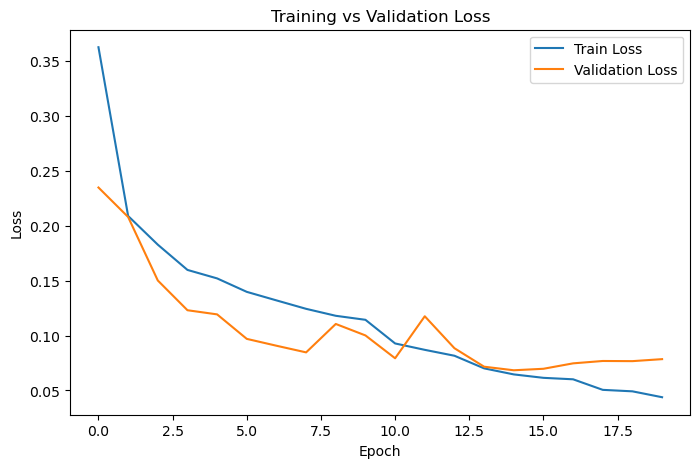

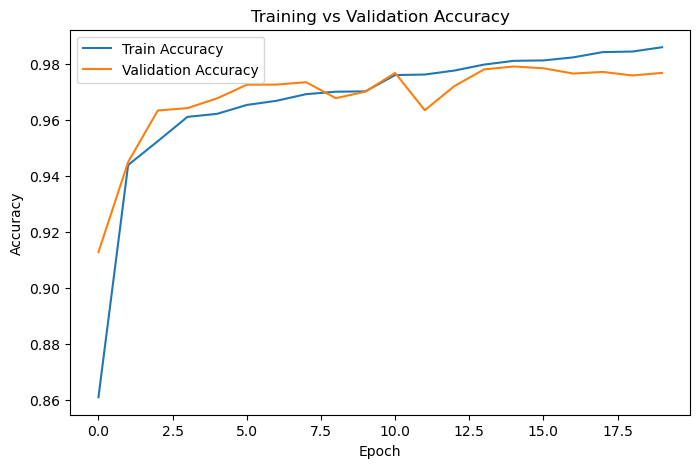

685/685 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step
Probability stats:
Min : 1.3233045e-08
Max : 1.0
Mean: 0.18613254

Threshold tuning:

Threshold 0.50 | Precision 0.9327 | Recall 0.9441 | F1 0.9384
Threshold 0.55 | Precision 0.9399 | Recall 0.9414 | F1 0.9407
Threshold 0.60 | Precision 0.9490 | Recall 0.9377 | F1 0.9434
Threshold 0.65 | Precision 0.9560 | Recall 0.9332 | F1 0.9445
Threshold 0.70 | Precision 0.9621 | Recall 0.9290 | F1 0.9453
Threshold 0.75 | Precision 0.9671 | Recall 0.9263 | F1 0.9463
Threshold 0.80 | Precision 0.9709 | Recall 0.9205 | F1 0.9450
Threshold 0.85 | Precision 0.9760 | Recall 0.9152 | F1 0.9446
Threshold 0.90 | Precision 0.9799 | Recall 0.9033 | F1 0.9400

Chosen threshold: 0.9000000000000004
Chosen metrics   : (0.9798792756539235, 0.9032856385797562, 0.9400248173169723)

Final Test Results
Accuracy              : 0.9801
Precision (Normal=0)  : 0.9802
Precision (Abnormal=1): 0.9799
Recall    (Abnormal=1): 0.9033
F1 Score  (Abnormal=1): 0.94
ROC-AUC               

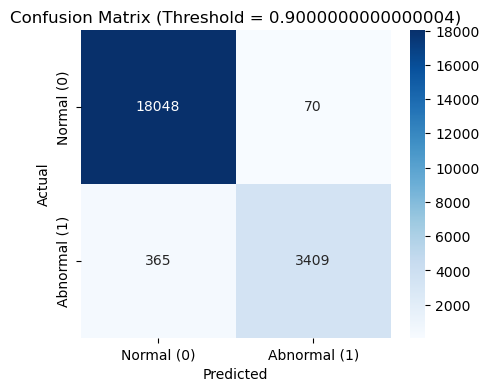


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18118
           1       0.98      0.90      0.94      3774

    accuracy                           0.98     21892
   macro avg       0.98      0.95      0.96     21892
weighted avg       0.98      0.98      0.98     21892



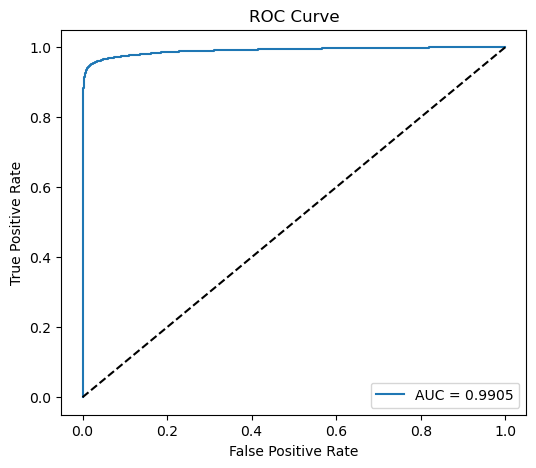

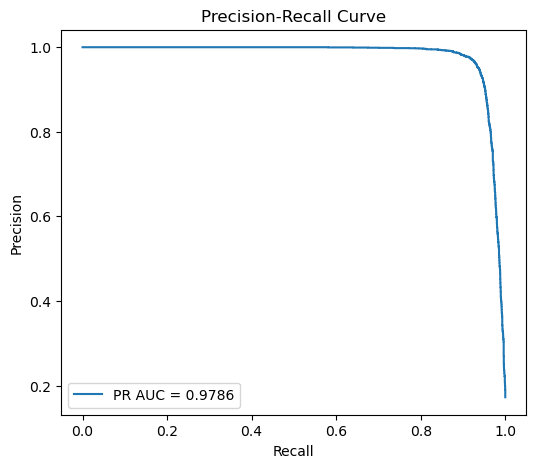

In [10]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================
# FILE PATHS
# =========================
train_path = R"C:\Users\ASUS\Documents\Python\New folder\mitbih_train.csv"
test_path  = R"C:\Users\ASUS\Documents\Python\New folder\mitbih_test.csv"

# =========================
# LOAD DATA
# =========================
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

# =========================
# FEATURES AND LABELS
# Last column = label
# =========================
X = train_df.iloc[:, :-1].values.astype(np.float32)
y = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values.astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(int)

# =========================
# CONVERT TO BINARY
# 0 = normal
# 1,2,3,4 = abnormal -> 1
# =========================
y = np.where(y == 0, 0, 1).astype(int)
y_test = np.where(y_test == 0, 0, 1).astype(int)

print("Train label distribution:", np.bincount(y))
print("Test label distribution :", np.bincount(y_test))

# =========================
# TRAIN-VALIDATION SPLIT
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

print("Train split:", np.bincount(y_train))
print("Val split  :", np.bincount(y_val))

# =========================
# SCALE FEATURES
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# RESHAPE FOR MODEL
# (samples, timesteps, channels)
# =========================
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

# =========================
# CLASS WEIGHTS
# =========================
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

# =========================
# TRANSFORMER ENCODER BLOCK
# =========================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])

    y = LayerNormalization(epsilon=1e-6)(x)
    y = Dense(ff_dim, activation="relu")(y)
    y = Dropout(dropout)(y)
    y = Dense(int(x.shape[-1]))(y)
    return Add()([x, y])

# =========================
# CNN + TRANSFORMER MODEL
# =========================
input_layer = Input(shape=(X_train.shape[1], 1))

x = Conv1D(32, kernel_size=5, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=2)(x)

x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.1)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)

output_layer = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output_layer)

# =========================
# COMPILE MODEL
# =========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# =========================
# TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    shuffle=True,
    verbose=1
)

# =========================
# PLOT TRAINING CURVES
# =========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# =========================
# PREDICT PROBABILITIES
# =========================
y_prob = model.predict(X_test).flatten()

print("Probability stats:")
print("Min :", y_prob.min())
print("Max :", y_prob.max())
print("Mean:", y_prob.mean())

# =========================
# THRESHOLD TUNING
# =========================
print("\nThreshold tuning:\n")

best_threshold = 0.6
best_precision = -1
best_stats = None

for t in np.arange(0.50, 0.91, 0.05):
    y_pred_temp = (y_prob >= t).astype(int)

    prec = precision_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, pos_label=1, zero_division=0)

    print(f"Threshold {t:.2f} | Precision {prec:.4f} | Recall {rec:.4f} | F1 {f1:.4f}")

    if rec >= 0.90 and prec > best_precision:
        best_precision = prec
        best_threshold = t
        best_stats = (prec, rec, f1)

print("\nChosen threshold:", best_threshold)
print("Chosen metrics   :", best_stats)

# =========================
# FINAL PREDICTIONS
# =========================
y_pred = (y_prob >= best_threshold).astype(int)

# =========================
# FINAL METRICS
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision_abnormal = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_abnormal = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_abnormal = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
precision_normal = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nFinal Test Results")
print("Accuracy              :", round(accuracy, 4))
print("Precision (Normal=0)  :", round(precision_normal, 4))
print("Precision (Abnormal=1):", round(precision_abnormal, 4))
print("Recall    (Abnormal=1):", round(recall_abnormal, 4))
print("F1 Score  (Abnormal=1):", round(f1_abnormal, 4))
print("ROC-AUC               :", round(roc_auc, 4))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal (0)', 'Abnormal (1)'],
    yticklabels=['Normal (0)', 'Abnormal (1)']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Threshold = {best_threshold})")
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_curve:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# =========================
# PRECISION-RECALL CURVE
# =========================
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [11]:
import pandas as pd

data = {
    "Model": ["CNN", "Hybrid CNN-Transformer"],
    "Accuracy": [0.982, 0.9797],
    "Precision (Abnormal)": [0.94, 0.98],
    "Recall (Abnormal)": [0.95, 0.90],
    "F1 Score": [0.95, 0.94],
    "ROC-AUC": [0.9928, 0.9904]
}

df = pd.DataFrame(data)
print(df)

                    Model  Accuracy  Precision (Abnormal)  Recall (Abnormal)  \
0                     CNN    0.9820                  0.94               0.95   
1  Hybrid CNN-Transformer    0.9797                  0.98               0.90   

   F1 Score  ROC-AUC  
0      0.95   0.9928  
1      0.94   0.9904  


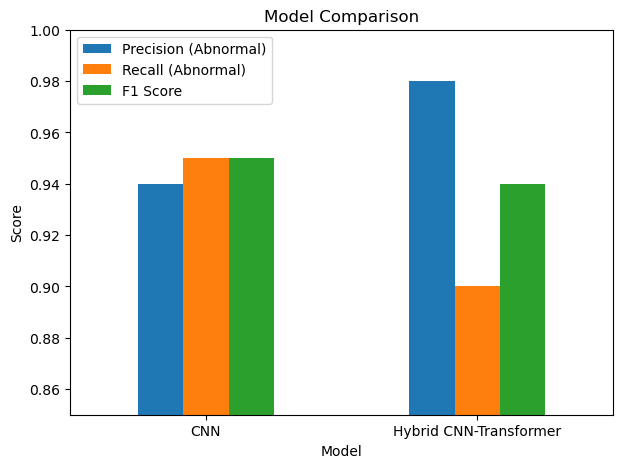

In [12]:
import matplotlib.pyplot as plt

df.set_index("Model")[["Precision (Abnormal)", "Recall (Abnormal)", "F1 Score"]].plot(kind='bar', figsize=(7,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.85, 1.0)
plt.legend()
plt.show()

                    Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0                     CNN    0.9773     0.9724  0.9152    0.9430   0.9928
1  Hybrid CNN-Transformer    0.9758     0.9765  0.8810    0.9263   0.9894


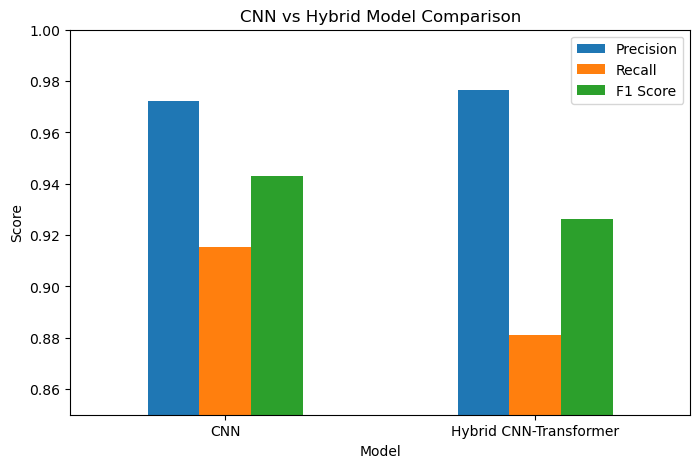

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["CNN", "Hybrid CNN-Transformer"],
    "Accuracy": [0.9773, 0.9758],
    "Precision": [0.9724, 0.9765],
    "Recall": [0.9152, 0.8810],
    "F1 Score": [0.9430, 0.9263],
    "ROC-AUC": [0.9928, 0.9894]
})

print(comparison_df)

comparison_df.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(8,5))
plt.ylim(0.85, 1.00)
plt.ylabel("Score")
plt.title("CNN vs Hybrid Model Comparison")
plt.xticks(rotation=0)
plt.show()